In [143]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from setup import *
from plts_funcs import *

stiles = ['-', '--', '-.', ':', ""]
colors = ["blue", "orange", "lightgreen", "red", "purple"]

## corrugation modes model

$\omega = m \Omega_{\phi} - j^{1/2} \Omega_\theta$

calcolate a $r_{ivr}$, raggio di risonanza verticale, definito proprio come il valore per cui quell'uguagliaanza è soddisfatta fissata la frequenza.

In [144]:
def c_fq(m, j, a, rivr, M=M_BH):
    rivr = np.asarray(rivr)
    a = np.asarray(a)
    M = np.asarray(M)
    j = np.asarray(j)
    m = np.asarray(m)

    return m * nu_phi(rivr, a, M) - np.sqrt(j) * nu_theta(rivr, a, M)

#### visualizzazione

In [145]:
# ============================================================
# PARAMETRI DEL MODO
# ============================================================
m_values = [1, 2, 3]  # valori di m sulle righe
n_values = [1, 2, 3]  # valori di n sulle colonne (per confronto)
A = 1                  # ampiezza della deformazione (adimensionale)
omega = 1.0           # frequenza del modo (unità arbitrarie)

# Tre istanti temporali per vedere l'oscillazione
t_values = [0.0, np.pi/(2*omega), np.pi/omega]  # t=0, t=T/4, t=T/2

# ============================================================
# GRIGLIA DEL DISCO
# ============================================================
r_in = 5
r_out = 15
Nr = 100  # Ridotto per performance
Nphi = 150

r = np.linspace(r_in, r_out, Nr)
phi = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r, phi)

# ============================================================
# PROFILO RADIALE (trapping vicino al bordo interno)
# ============================================================
r0 = r_in + 3
sigma = 2.5
radial_profile = np.exp(-((R - r0)**2) / sigma**2)

# ============================================================
# COORDINATE CARTESIANE (base)
# ============================================================
X = R * np.cos(PHI)
Y = R * np.sin(PHI)

##### n fisso

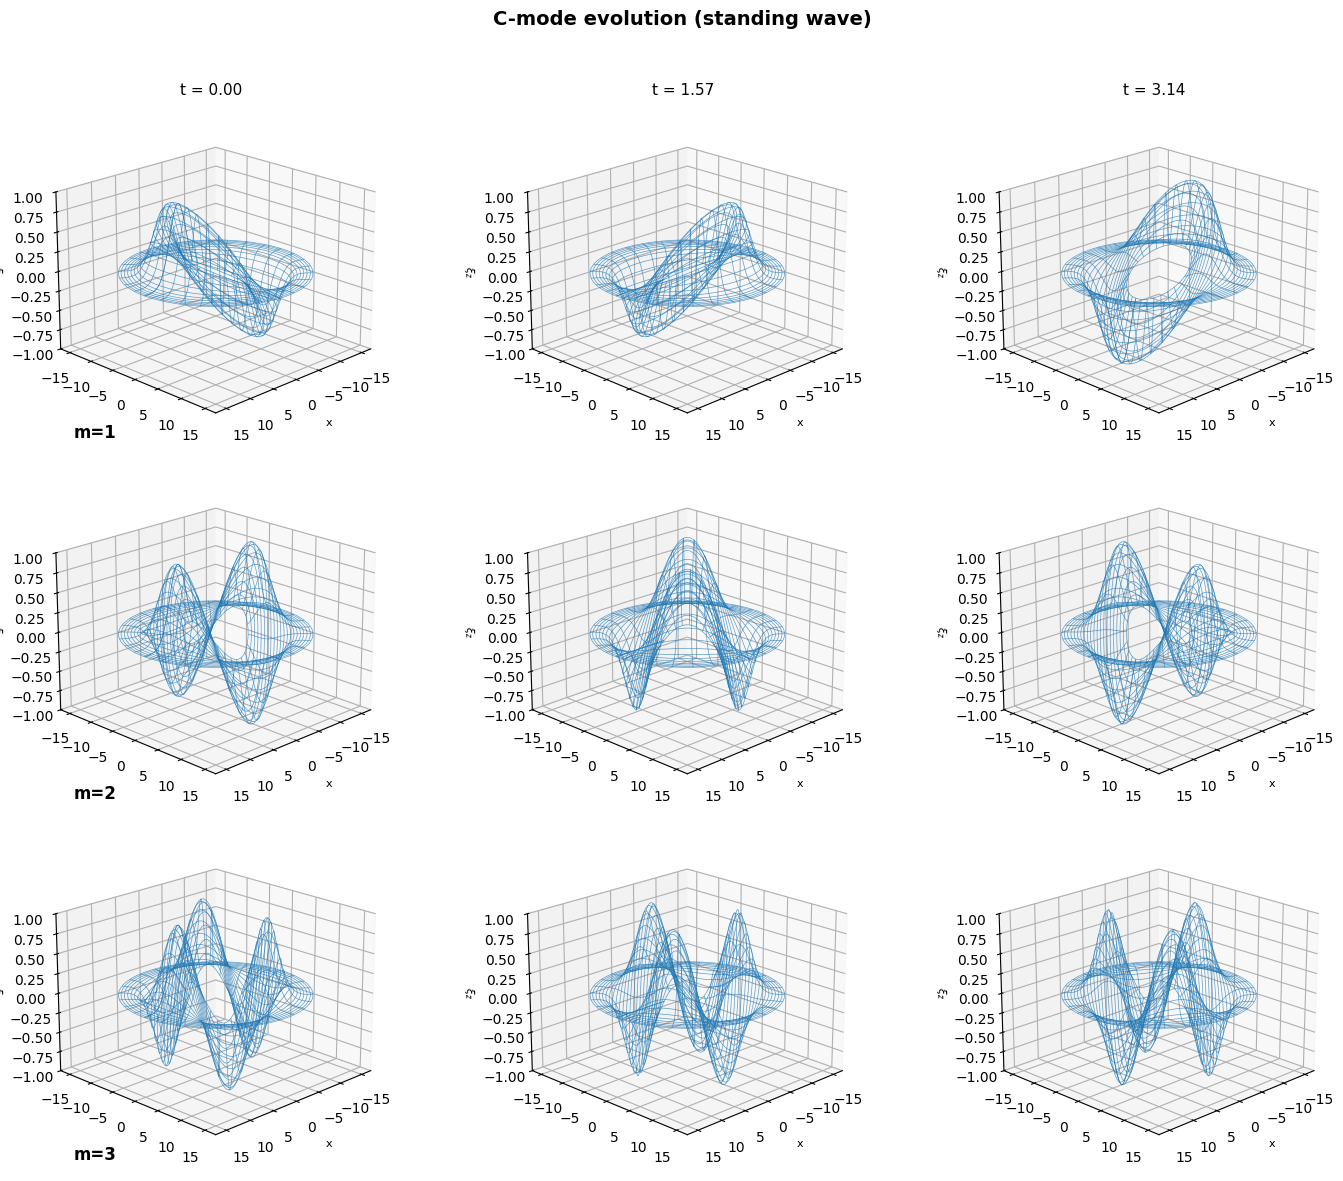

In [146]:
# ============================================================
# PLOT 3x3 GRID
# ============================================================
fig = plt.figure(figsize=(15, 12))

for i, m in enumerate(m_values):
    for j, t in enumerate(t_values):
        # Calcola lo spostamento verticale per questo (m, t)
        # Uso n=1 per semplicità, ma puoi variare anche n se vuoi
        xi_z = A * radial_profile * np.cos(m * PHI - omega * t)
        Z = xi_z
        
        # Crea subplot
        ax = fig.add_subplot(3, 3, i*3 + j + 1, projection='3d')
        
        # Plot wireframe
        ax.plot_wireframe(X, Y, Z, rstride=5, cstride=5, alpha=0.7, linewidth=0.5)
        
        # Titolo e labels
        if j == 0:  # Prima colonna: mostra m
            ax.set_ylabel(f"m={m}", fontsize=12, fontweight='bold', labelpad=10)
        if i == 0:  # Prima riga: mostra tempo
            ax.set_title(f"t = {t:.2f}", fontsize=11)
        
        ax.set_xlabel("x", fontsize=8)
        ax.set_zlabel(r"$\xi_z$", fontsize=8)
        
        # Limiti fissi per confronto
        ax.set_zlim(-A, A)
        
        # Angolo di vista
        ax.view_init(elev=20, azim=45)
        
        # Griglia
        ax.grid(True, alpha=0.3)

fig.suptitle("C-mode evolution (standing wave)", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

##### m fisso

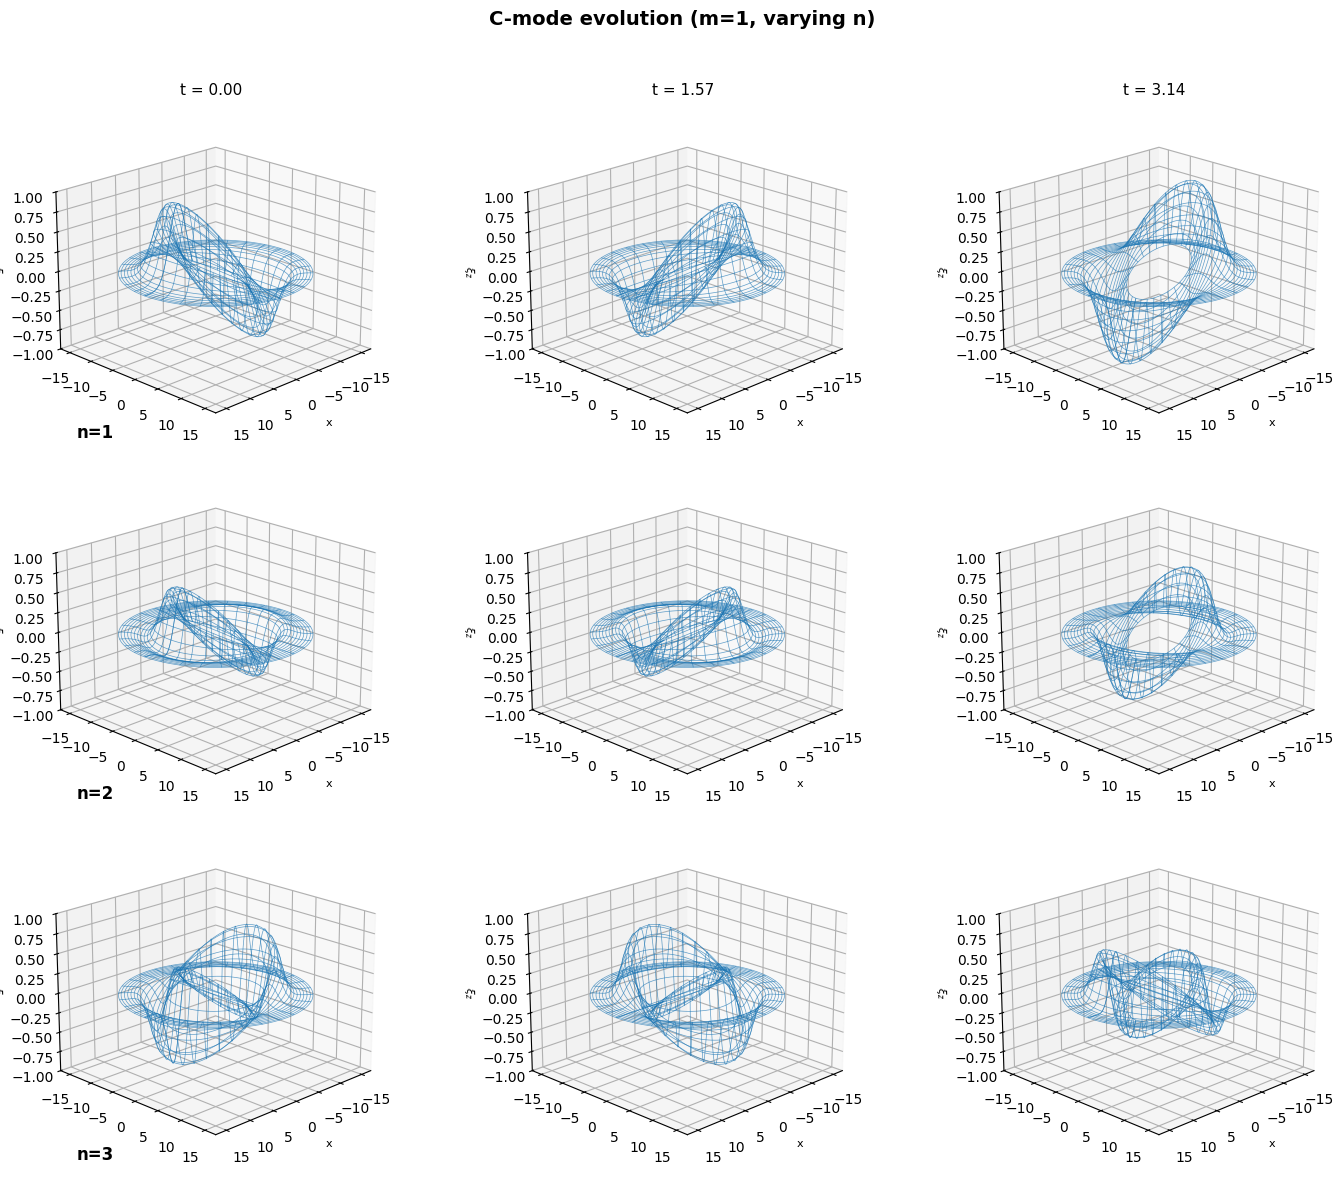

In [147]:
# ============================================================
# PLOT 3x3 GRID (n sulle righe, t sulle colonne)
# ============================================================
fig = plt.figure(figsize=(15, 12))

m = 1
for i, n in enumerate(n_values):
    for j, t in enumerate(t_values):
        # Modifica il profilo radiale per n diversi
        # Per n più alti, potresti volere più nodi radiali
        if n == 1:
            radial_mod = radial_profile
        elif n == 2:
            # Aggiungi struttura radiale
            radial_mod = radial_profile * np.cos(np.pi * (R - r_in) / (r_out - r_in))
        else:  # n == 3
            radial_mod = radial_profile * np.cos(2 * np.pi * (R - r_in) / (r_out - r_in))
        
        # Calcola spostamento
        xi_z = A * radial_mod * np.cos(m * PHI - omega * t)
        Z = xi_z
        
        # Crea subplot
        ax = fig.add_subplot(3, 3, i*3 + j + 1, projection='3d')
        
        # Plot wireframe
        ax.plot_wireframe(X, Y, Z, rstride=5, cstride=5, alpha=0.7, linewidth=0.5)
        
        # Titoli
        if j == 0:  # Prima colonna
            ax.set_ylabel(f"n={n}", fontsize=12, fontweight='bold', labelpad=10)
        if i == 0:  # Prima riga
            ax.set_title(f"t = {t:.2f}", fontsize=11)
        
        ax.set_xlabel("x", fontsize=8)
        ax.set_zlabel(r"$\xi_z$", fontsize=8)
        
        # Limiti fissi
        ax.set_zlim(-A, A)
        ax.view_init(elev=20, azim=45)
        ax.grid(True, alpha=0.3)

fig.suptitle(f"C-mode evolution (m={m}, varying n)", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 1 - no insight fisiche, solo trovare rivr con r_in fissato a isco.

si può fare perché la frequenza sopra è fissata indipendentemente da rin

M fissata

In [148]:
params = {
    "m": (0, 3, 4),
    "j": (0, 3, 4),
    "a": (-0.99, 0.99, 199),
    "rivr": (1, 500, 200)
}
labels = list(params.keys())
param_vectors, mesh_arrays = create_param_grid(params)

m, j, A, RIVR = mesh_arrays

RIVR = np.maximum(RIVR, r_isco(A))

In [149]:
freq = c_fq(m, j, A, RIVR)

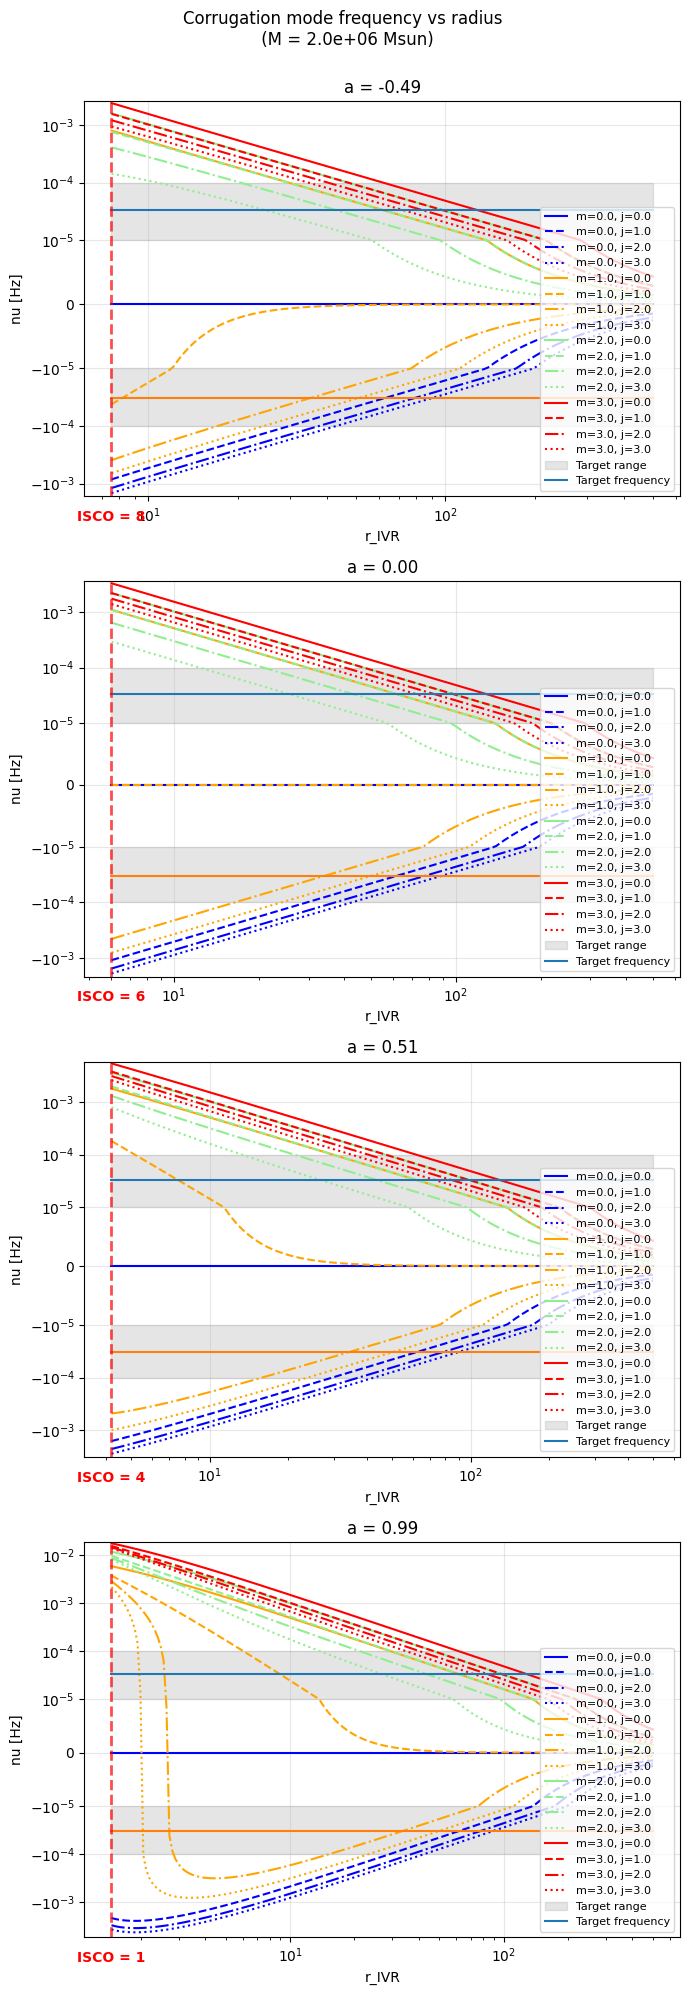

In [150]:
fig, axes = plt.subplots(4, 1, figsize=(7, 20))
axes = axes.flatten()

fig.suptitle(f"Corrugation mode frequency vs radius \n (M = {M_BH:.1e} Msun)", y=0.995)

a_idx = [50, 99, 150, 198]

# Loop over zeta values
for i, ia in enumerate(a_idx):
    for im, mm in enumerate(m):
        for ij, jj in enumerate(j):
            r_vals = RIVR[im, ij, ia, :]
            freq_vals = freq[im, ij, ia, :]    # vector shape (No,)

            # plot only valid positive frequencies
            mask = np.isfinite(freq_vals)

            jj = j[im, ij, ia, 0]
            mm = m[im, ij, ia, 0]

            label = f"m={mm}, j={jj}"
            axes[i].plot(r_vals[mask], freq_vals[mask], label=label, 
                         linestyle=stiles[ij % len(stiles)],
                         color=colors[im % len(colors)])

    # Target frequency band
    axes[i].fill_between(r_vals, TARGET_MIN, TARGET_MAX, color='gray', alpha=0.2,
                    label="Target range")
    axes[i].plot(r_vals, np.ones_like(r_vals)*NU0, label="Target frequency")

    # Target frequency band negative ones
    axes[i].fill_between(r_vals, -TARGET_MIN, -TARGET_MAX, color='gray', alpha=0.2)
    axes[i].plot(r_vals, -np.ones_like(r_vals)*NU0)

    # Linea verticale
    r_fixed = r_isco(A[0,0,ia,0])
    axes[i].axvline(x=r_fixed, color='red', linestyle='--', linewidth=2, alpha=0.7)

    axes[i].set_title(f"a = {A[0,0,ia,0]:.2f}")
    axes[i].set_xlabel("r_IVR")
    axes[i].set_ylabel("nu [Hz]")
    axes[i].set_yscale("symlog", linthresh=1e-5)
    axes[i].set_xscale("log")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8, loc='lower right')

    # Aggiungi testo sotto l'asse x
    axes[i].annotate(f'ISCO = {r_fixed:.0f}', 
                xy=(r_fixed, 0), xycoords=('data', 'axes fraction'),
                xytext=(0, -10), textcoords='offset points',
                ha='center', va='top',
                color='red', fontweight='bold', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()


> j=m=1 è lense-thirring precession, infatti omega=0 se a=0 e si inverte se lo spin diventa positivo (la precessione è sempre nella direzione del momento angolare e quindi è prograda o retrograda a seconda dello spin)
> solo questa matcha per raggi piccoli, a meno che lo spin non sia molto grande
>> in quel caso anche modi verticali più alti matchano, sia progradi che retrogradi a raggi vicini.

> per tutti gli altri modi, il match si ha per raggi motlo più grandi, oltre i 30 Rg.
>> questi saranno in realtà non cmodes ma g modes, perché stanno in regione di propagazione diversa, come vedremo dal grafico sotto

> aggiunbgengo n=0 e m=0 studiamo anche i p modes e i gmodes associati: veidamo comportamento analogo, matrch sempre a ragi più grandi, in regione che credo sia gmodes, ma poi verifichiamo. )p modes han frq più alta a parità di raggio)
>> m=n=0 non dà nulla ovviamente

#### regioni di propagazione
dipendono da spin m e j

In [151]:
def plots_frq(ax, r_vals, all_frequencies, mm, jj):
    # Plot mΩ + κ (outer LR)
    ax.plot(r_vals, all_frequencies[1],
                color="red", linestyle="-", linewidth=2,
                #label=r'$m \nu_\varphi + \nu_r$'
                )
    
    # Plot mΩ + nΩ⊥/20 (g-mode upper boundary)
    ax.plot(r_vals, all_frequencies[3],
                   color="green", linestyle="-.", linewidth=1.5, 
                    #label=r'$m \nu_\varphi + \sqrt{j} \nu_\vartheta$'
                    )
    
    if mm > 0:
        # Plot mΩ (linea di riferimento tratteggiata)
        ax.plot(r_vals, all_frequencies[0], color="black", 
                    linestyle=':', linewidth=1.5, 
                    #label=r'$m \nu_\varphi$'
                    )
        
        # Plot mΩ - κ (inner LR)
        ax.plot(r_vals, all_frequencies[2],
                    color="red", linestyle="-", linewidth=2,
                    #label=r'$m \nu_\varphi - \nu_r$'
                    )
        # Plot mΩ - nΩ⊥/20 (g-mode upper boundary)
        ax.plot(r_vals, all_frequencies[4],
                        color="green", linestyle="-.", linewidth=1.5, 
                        #label=r'$m \nu_\varphi - \sqrt{j} \nu_\vartheta$'
                        )

In [152]:
def add_texts(ax, r_vals, m_Omega, freq_plus_kappa, freq_minus_kappa, freq_plus_n20, freq_minus_n20, r_isco_val, mm, jj):
    # Posiziona le etichette sulle curve
    # Scegli un indice per il posizionamento (es. 60% lungo la curva)
    idx = int(len(r_vals) * 0.6)
    
    # Etichetta per mΩ (solo se mm > 0)
    if mm > 0:
        ax.text(r_vals[idx], m_Omega[idx], r'$m \nu_\varphi$', 
                    fontsize=10, ha='left', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                edgecolor='none', alpha=0.7))
    
    # Etichetta per mΩ + κ
    idx_outer = int(len(r_vals) * 0.5)
    ax.text(r_vals[idx_outer], freq_plus_kappa[idx_outer], 
                r'$m \nu_\varphi + \nu_r$', 
                fontsize=10, ha='left', va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                            edgecolor='none', alpha=0.7))
    
    # Etichetta per mΩ - κ (solo se mm > 0 e non NaN)
    if mm > 0 and not np.isnan(freq_minus_kappa).all():
        idx_inner = int(len(r_vals) * 0.4)
        ax.text(r_vals[idx_inner], freq_minus_kappa[idx_inner], 
                    r'$m \nu_\varphi - \nu_r$', 
                    fontsize=10, ha='left', va='top',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                edgecolor='none', alpha=0.7))

    # Etichetta per mΩ + nΩ⊥
    if jj > 0:
        idx_upper = int(len(r_vals) * 0.8)
        if mm > 0 and not np.isnan(freq_plus_n20[idx_upper]):  # AGGIUNGI mm > 0
            ax.text(r_vals[idx_upper], freq_plus_n20[idx_upper], 
                        r'$m\Omega+\sqrt{j}\Omega_\perp$', 
                        fontsize=9, ha='right', va='bottom',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                    edgecolor='none', alpha=0.7))
            
        # Etichetta per mΩ - nΩ⊥ (solo se mm > 0 e non NaN)
        if mm > 0 and not np.isnan(freq_minus_n20).all():
            ax.text(r_vals[idx_upper], freq_minus_n20[idx_upper], 
                        r'$m \nu_\varphi - \sqrt{j} \nu_\vartheta$', 
                        fontsize=9, ha='right', va='top',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                    edgecolor='none', alpha=0.7))


    # Linea verticale per r_ISCO
    ax.axvline(r_isco_val, color='black', linestyle='--', 
                    linewidth=0.5, alpha=0.5)

In [153]:
def find_continuous_segments(mask):
    """
    Trova segmenti continui di True in una maschera booleana.
    Ritorna lista di tuple (start_idx, end_idx)
    """
    segments = []
    in_segment = False
    start = 0
    
    for i, val in enumerate(mask):
        if val and not in_segment:
            start = i
            in_segment = True
        elif not val and in_segment:
            segments.append((start, i-1))
            in_segment = False
    
    if in_segment:
        segments.append((start, len(mask)-1))
    
    return segments

In [154]:
def plot_target_frequency_wavy(ax, r_vals, freq_plus_kappa, freq_minus_kappa, 
                               freq_plus_n20, freq_minus_n20, target_freq, mm, jj):
    """
    Plotta la target frequency come linea ondulata solo nelle regioni consentite.
    
    Regole:
    - j=0 (qualunque m): p-modes all'esterno delle curve rosse (freq > mΩ+κ o freq < mΩ-κ)
    - m=0, j>0: g-modes intrappolati dentro mΩ+κ E p-modes oltre mΩ+√jΩ⊥
    - m>0, j>0: g-modes tra mΩ-κ e mΩ+κ, 
                c-modes sotto mΩ-√jΩ⊥ (quando è positivo),
                p-modes oltre mΩ+√jΩ⊥ (superiore) e oltre mΩ-√jΩ⊥ (quando diventa negativo)
    """
    
    # Crea la linea ondulata
    n_waves = 20
    wave_amplitude = target_freq * 0.1
    
    log_r = np.log10(r_vals)
    log_r_normalized = (log_r - log_r.min()) / (log_r.max() - log_r.min())
    wave = wave_amplitude * np.sin(2 * np.pi * n_waves * log_r_normalized)
    
    target_wavy_pos = target_freq + wave
    target_wavy_neg = -target_freq + wave  # frequenza negativa
    
    # Caso 1: j = 0 (qualunque m) -> solo p-modes
    if jj == 0:
        # p-modes: oltre mΩ+κ
        p_mode_mask = (target_wavy_pos >= freq_plus_kappa) & ~np.isnan(freq_plus_kappa)
        
        if np.any(p_mode_mask):
            segments = find_continuous_segments(p_mode_mask)
            for start, end in segments:
                ax.plot(r_vals[start:end+1], target_wavy_pos[start:end+1], 
                       color='orange', linewidth=2, linestyle='-',
                       label='Target (p-mode)' if start == segments[0][0] else '')
    
        # p-modes: sotto mΩ-κ
        if mm > 0:
            p_mode_mask_neg = (target_wavy_pos <= freq_minus_kappa) & ~np.isnan(freq_minus_kappa)
            if np.any(p_mode_mask_neg):
                segments_neg = find_continuous_segments(p_mode_mask_neg)
                for start, end in segments_neg:
                    ax.plot(r_vals[start:end+1], target_wavy_pos[start:end+1], 
                        color='orange', linewidth=2, linestyle='-')

    # Caso 2: m = 0, j > 0
    elif mm == 0 and jj > 0:
        # g-modes: intrappolati dentro mΩ+κ (sotto la curva rossa)
        g_mode_mask = (target_wavy_pos <= freq_plus_kappa) & (target_wavy_pos > 0)
        g_mode_mask = g_mode_mask & ~np.isnan(freq_plus_kappa)
        
        # p-modes: oltre mΩ+√jΩ⊥ (oltre la curva verde superiore)
        p_mode_mask = (target_wavy_pos >= freq_plus_n20) & ~np.isnan(freq_plus_n20)
        
        if np.any(g_mode_mask):
            segments_g = find_continuous_segments(g_mode_mask)
            for start, end in segments_g:
                ax.plot(r_vals[start:end+1], target_wavy_pos[start:end+1], 
                       color='blue', linewidth=2, linestyle='-',
                       label='Target (g-mode)' if start == segments_g[0][0] else '')
        
        if np.any(p_mode_mask):
            segments_p = find_continuous_segments(p_mode_mask)
            for start, end in segments_p:
                ax.plot(r_vals[start:end+1], target_wavy_pos[start:end+1], 
                       color='orange', linewidth=2, linestyle='-',
                       label='Target (p-mode)' if start == segments_p[0][0] else '')
    
    # Caso 3: m > 0, j > 0
    elif mm > 0 and jj > 0:
        # g-modes: tra mΩ-κ e mΩ+κ
        g_mode_mask = (target_wavy_pos >= freq_minus_kappa) & (target_wavy_pos <= freq_plus_kappa)
        g_mode_mask = g_mode_mask & ~np.isnan(freq_minus_kappa) & ~np.isnan(freq_plus_kappa)
        
        # Separare le regioni dove freq_minus_n20 è positiva vs negativa
        positive_n20_mask = (freq_minus_n20 > 0) & ~np.isnan(freq_minus_n20)
        negative_n20_mask = (freq_minus_n20 < 0) & ~np.isnan(freq_minus_n20)
        
        # c-modes: sotto mΩ-√jΩ⊥ quando è positivo
        c_mode_mask = (target_wavy_pos <= freq_minus_n20) & positive_n20_mask & (target_wavy_pos > 0)
        
        # p-modes (superiori): oltre mΩ+√jΩ⊥
        p_mode_upper_mask = (target_wavy_pos >= freq_plus_n20) & ~np.isnan(freq_plus_n20)
        
        # p-modes (inferiori negativi): oltre mΩ-√jΩ⊥ quando è negativo
        # "oltre" significa più negativo della curva negativa
        p_mode_lower_neg_mask = (target_wavy_neg <= freq_minus_n20) & negative_n20_mask
        
        # Plot g-modes
        if np.any(g_mode_mask):
            segments_g = find_continuous_segments(g_mode_mask)
            for start, end in segments_g:
                ax.plot(r_vals[start:end+1], target_wavy_pos[start:end+1], 
                       color='blue', linewidth=2, linestyle='-',
                       label='Target (g-mode)' if start == segments_g[0][0] else '')
        
        # Plot c-modes (solo dove freq_minus_n20 > 0)
        if np.any(c_mode_mask):
            segments_c = find_continuous_segments(c_mode_mask)
            c_label_added = False
            for start, end in segments_c:
                ax.plot(r_vals[start:end+1], target_wavy_pos[start:end+1], 
                       color='purple', linewidth=2, linestyle='-',
                       label='Target (c-mode)' if not c_label_added else '')
                c_label_added = True
        
        # Plot p-modes superiori
        if np.any(p_mode_upper_mask):
            segments_p_upper = find_continuous_segments(p_mode_upper_mask)
            p_label_added = False
            for start, end in segments_p_upper:
                ax.plot(r_vals[start:end+1], target_wavy_pos[start:end+1], 
                       color='orange', linewidth=2, linestyle='-',
                       label='Target (p-mode)' if not p_label_added else '')
                p_label_added = True
        
        # Plot p-modes inferiori (quando freq_minus_n20 diventa negativo)
        if np.any(p_mode_lower_neg_mask):
            segments_p_lower = find_continuous_segments(p_mode_lower_neg_mask)
            for start, end in segments_p_lower:
                ax.plot(r_vals[start:end+1], target_wavy_neg[start:end+1], 
                       color='orange', linewidth=2, linestyle='-',
                       label='Target (p-mode)' if not p_label_added else '')
                p_label_added = True
    
    # Caso 4: m > 0, j = 0
    elif mm > 0 and jj == 0:
        # p-modes: oltre mΩ+κ
        p_mode_mask = (target_wavy_pos >= freq_plus_kappa) & ~np.isnan(freq_plus_kappa)
        
        if np.any(p_mode_mask):
            segments = find_continuous_segments(p_mode_mask)
            for start, end in segments:
                ax.plot(r_vals[start:end+1], target_wavy_pos[start:end+1], 
                       color='orange', linewidth=2, linestyle='-',
                       label='Target (p-mode)' if start == segments[0][0] else '')

/home/masterpops/IUSS_tesi/setup.py:192: RuntimeWarning: invalid value encountered in sqrt
  factor = np.sqrt(1 - (6)/r + (8*a)/r**1.5 - (3*a**2)/r**2)


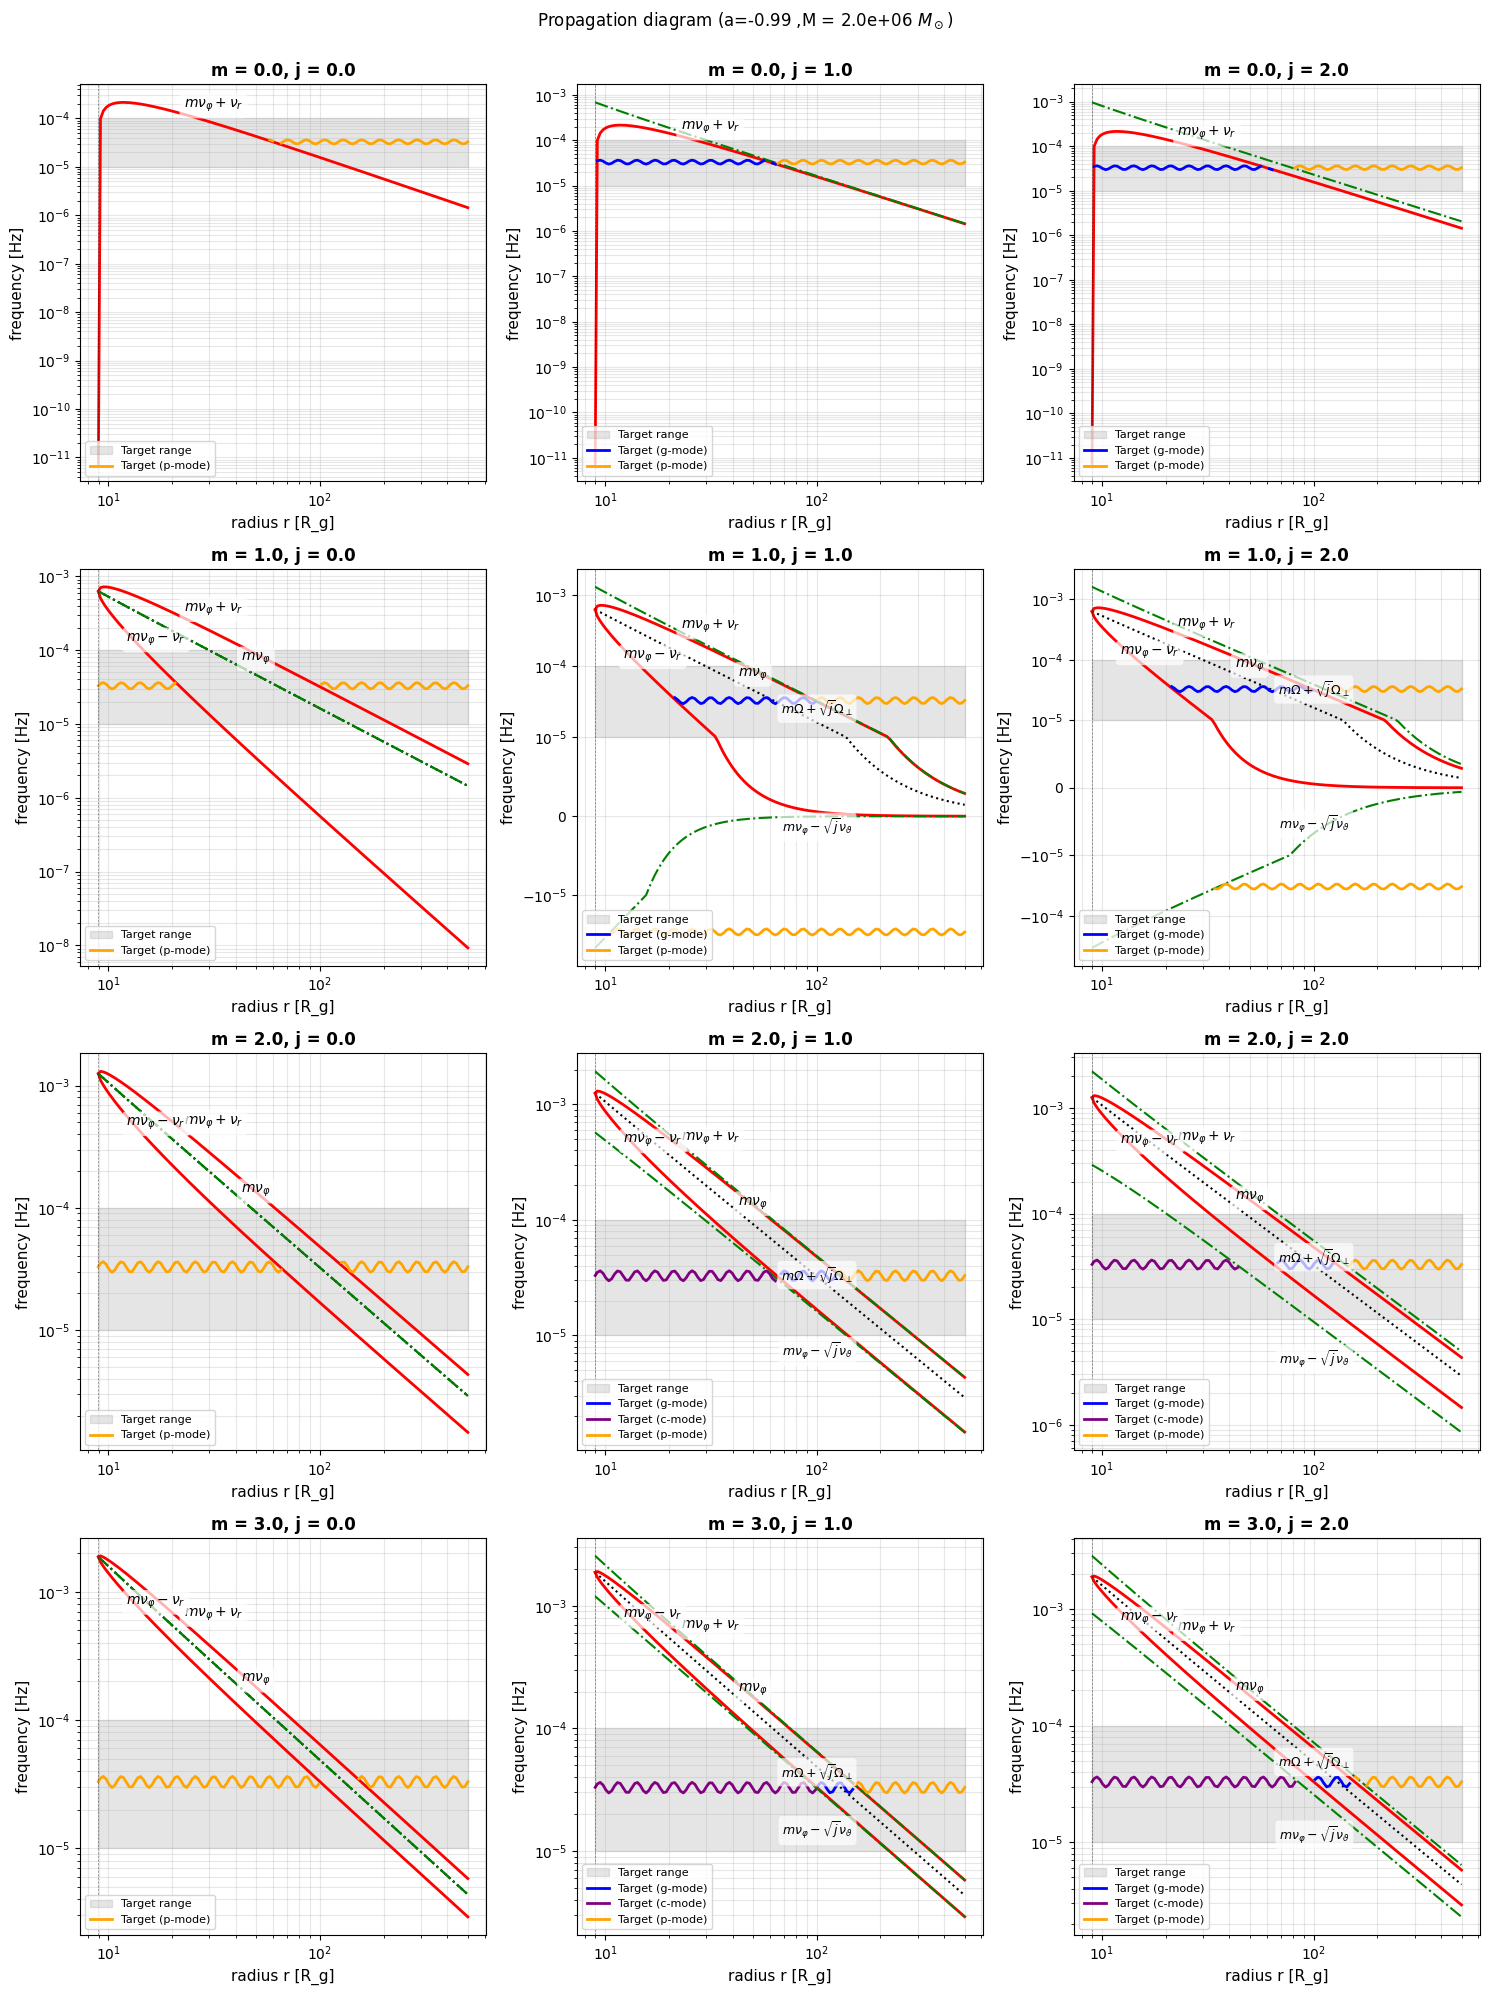

In [155]:
Omega = nu_phi(RIVR, A)  # Ω (frequenza orbitale azimutale)
Omega_perp = nu_theta(RIVR, A)  # Ω⊥ (frequenza epicyclica verticale)
kappa = nu_r(RIVR, A)  # κ (frequenza epicyclica radiale)

ia = 0

fig, axes = plt.subplots(4, 3, figsize=(15, 20))
#axes = axes.flatten()
fig.suptitle(fr"Propagation diagram (a={A[0,0,ia,0]:.2f} ,M = {M_BH:.1e} $M_\odot$)", y=0.995)

a_val = A[0, 0, ia, 0]
r_isco_val = r_isco(A[0, 0, ia, 0])

for im in range(4):
    for ij in range(3):
        mm = m[im,ij,ia,0]
        jj = j[im,ij,ia,0]

        # Estrai le slice corrette per questa combinazione (im, ij, ia)
        m_Omega = mm * Omega[im, ij, ia, :]  # shape (200,)
        freq_plus_kappa = m_Omega + kappa[im, ij, ia, :]
        freq_plus_n20 = m_Omega + Omega_perp[im, ij, ia, :] * np.sqrt(jj)
        if mm > 0:
            freq_minus_kappa = m_Omega - kappa[im, ij, ia, :]
            freq_minus_n20 = m_Omega - Omega_perp[im, ij, ia, :] * np.sqrt(jj)
            #freq_minus_n20 = np.abs(m_Omega - Omega_perp[im, ij, ia, :] * np.sqrt(jj))
        else:
            freq_minus_kappa = freq_plus_kappa
            freq_minus_n20 = freq_plus_n20

        # Raccogli tutti i dati
        all_frequencies = [m_Omega, freq_plus_kappa, freq_minus_kappa, 
                          freq_plus_n20, freq_minus_n20]
        # Determina la scala appropriata
        has_negative = any(np.any(freq < 0) for freq in all_frequencies)

        r_vals = RIVR[im, ij, ia, :]
    
        plots_frq(axes[im, ij], r_vals, all_frequencies, mm, jj)
            
        # Target frequency band
        axes[im, ij].fill_between(r_vals, TARGET_MIN, TARGET_MAX, color='gray', alpha=0.2,
                        label="Target range")
        plot_target_frequency_wavy(axes[im, ij], r_vals, freq_plus_kappa, freq_minus_kappa,
                           freq_plus_n20, freq_minus_n20, NU0, mm, jj)
        if has_negative:
            axes[im, ij].set_yscale("symlog", linthresh=1e-5)
        else:
            axes[im, ij].set_yscale("log")

        add_texts(axes[im, ij], r_vals, m_Omega, freq_plus_kappa, freq_minus_kappa, freq_plus_n20, freq_minus_n20, r_isco_val, mm, jj)

        # Etichette e formattazione
        axes[im, ij].set_title(f"m = {mm}, j = {jj}", fontsize=12, fontweight='bold')
        axes[im, ij].set_xlabel(r"radius r [R_g]", fontsize=11)
        axes[im, ij].set_ylabel("frequency [Hz]", fontsize=11)
        axes[im, ij].set_xscale("log")
        axes[im, ij].grid(True, alpha=0.3, which='both')
        axes[im, ij].legend(fontsize=8, loc="lower left")


plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()

### 2 - vediamo cosa cambia variando rin

insight semifisica, prendiamo rIVR in intorno di rin e individuiamo rin semplicemnente da questo. vedo la frequenza come funzione del raggio generico, e scelgo arbitrariamente un rin a il corrispondente rivr a cui valutarla per trovare il match

> in realtà credo che i risultati trovati al punto precedente siano generali, cioé a prescindere che il disco arrivi a ISCO o meno, i modi che possono spiegare quella frequenza sono quelli. semplicemente, se il disco non arriva a ISCO, magari alcuni non si possono vedere (tipo il cmode J=m=1 - che poi è LT quindi ha stesse limitazioni viste in RPM)

In [156]:
def c_frq(m, j, a, r, M=M_BH):
    r = np.asarray(r)
    a = np.asarray(a)
    M = np.asarray(M)
    j = np.asarray(j)
    m = np.asarray(m)

    return m * nu_phi(r, a, M) - np.sqrt(j) * nu_theta(r, a, M)

In [157]:
import sympy as sp

# --------------------------------------------------------
# PARTE 1: DERIVATA SIMBOLICA
# --------------------------------------------------------

# Definisci variabili simboliche
r_sym = sp.symbols('r', real=True, positive=True)
a_sym = sp.symbols('a', real=True)
M_sym = sp.symbols('M', real=True, positive=True)
m_sym = sp.symbols('m', real=True)
j_sym = sp.symbols('j', real=True, positive=True)

# Costanti fisiche (usa i valori da setup.py)
C_sym = C
Rg_SUN_sym = Rg_SUN

# Definisci nu_phi simbolicamente
def nu_phi_symbolic(r, a, M):
    Rg = Rg_SUN_sym * M
    return C_sym / (2*sp.pi * Rg*(r**sp.Rational(3,2) + a))

# Definisci nu_theta simbolicamente
def nu_theta_symbolic(r, a, M):
    vphi = nu_phi_symbolic(r, a, M)
    factor = sp.sqrt(1 - (4*a)/r**sp.Rational(3,2) + (3*a**2)/r**2)
    return vphi * factor

# Definisci c_frq simbolicamente
def c_frq_symbolic(m, j, a, r, M):
    return m * nu_phi_symbolic(r, a, M) - sp.sqrt(j) * nu_theta_symbolic(r, a, M)

In [158]:
# Calcola l'espressione simbolica
c_frq_expr = c_frq_symbolic(m_sym, j_sym, a_sym, r_sym, M_sym)

# Calcola la derivata rispetto a r
dc_frq_dr = sp.diff(c_frq_expr, r_sym)

# --------------------------------------------------------
# PARTE 2: CONVERTI IN FUNZIONE NUMERICA
# --------------------------------------------------------

# Converti in funzioni NumPy per calcoli veloci
c_frq_numeric = sp.lambdify((r_sym, a_sym, M_sym, m_sym, j_sym), 
                            c_frq_expr, 
                            modules='numpy')

dc_frq_dr_numeric = sp.lambdify((r_sym, a_sym, M_sym, m_sym, j_sym), 
                                dc_frq_dr, 
                                modules='numpy')

In [159]:
# --------------------------------------------------------
# PARTE 3: METODO DI NEWTON-RAPHSON
# --------------------------------------------------------

def find_rivr_newton(rin, a, m, j, nu0, M=M_BH, max_iter=50, tol=1e-10):
    """
    Trova rivr tale che c_frq(rivr) = nu0 usando Newton-Raphson:
    rivr_new = rivr - (c_frq(rivr) - nu0) / dc_frq_dr(rivr)
    
    Partendo da rivr = rin
    """
    rivr = rin
    
    for i in range(max_iter):
        # Valuta funzione e derivata
        f_val = c_frq_numeric(rivr, a, M, m, j) - nu0
        df_val = dc_frq_dr_numeric(rivr, a, M, m, j)
        
        # Evita divisione per zero
        if np.abs(df_val) < 1e-15:
            print(f"Derivata troppo piccola a iter {i}")
            break
        
        # Aggiornamento Newton-Raphson
        rivr_new = rivr - f_val / df_val
        
        # Check convergenza
        if np.abs(rivr_new - rivr) < tol:
            print(f"Convergenza raggiunta in {i+1} iterazioni")
            return rivr_new
        
        rivr = rivr_new
    
    print(f"Raggiunto max iterazioni ({max_iter})")
    return rivr

In [160]:
# --------------------------------------------------------
# PARTE 5: APPLICAZIONE VETTORIALE (se hai griglie)
# --------------------------------------------------------

def find_rivr_grid(rin_grid, a_grid, m_grid, j_grid, nu0, M=M_BH):
    """
    Applica Newton-Raphson a griglie di parametri.
    Tutti gli input devono avere la stessa shape.
    """
    rivr = rin_grid.copy()
    
    for i in range(50):
        f_val = c_frq_numeric(rivr, a_grid, M, m_grid, j_grid) - nu0
        df_val = dc_frq_dr_numeric(rivr, a_grid, M, m_grid, j_grid)
        
        # Maschera per evitare divisioni per zero
        mask = np.abs(df_val) > 1e-15
        
        delta = np.zeros_like(rivr)
        delta[mask] = f_val[mask] / df_val[mask]
        
        rivr_new = rivr - delta
        
        # Check convergenza
        if np.max(np.abs(rivr_new - rivr)) < 1e-10:
            print(f"Convergenza griglia in {i+1} iterazioni")
            break
        
        rivr = rivr_new
    
    return rivr

In [161]:
# Usa le tue griglie
params = {
    "m": (0, 3, 4),
    "j": (0, 3, 4),
    "a": (-0.99, 0.99, 199),
    "r": (1, 300, 200)
}
labels = list(params.keys())
param_vectors, mesh_arrays = create_param_grid(params)
m_grid, j_grid, a_grid, r_grid = mesh_arrays

# Applica vincolo ISCO
isco = r_isco(a_grid)
rin_grid = np.maximum(r_grid, isco)

# Calcola rivr per tutta la griglia
rivr_grid = find_rivr_grid(rin_grid, a_grid, m_grid, j_grid, NU0, M_BH)

print(f"\nShape risultato: {rivr_grid.shape}")
print(f"rivr min: {np.min(rivr_grid)}")
print(f"rivr max: {np.max(rivr_grid)}")

# Verifica quanto sono vicini a nu0
freq_check = c_frq_numeric(rivr_grid, a_grid, M_BH, m_grid, j_grid)
errors = np.abs(freq_check - NU0)
print(f"\nErrore massimo: {np.max(errors)}")
print(f"Errore medio: {np.mean(errors)}")

<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in power
  return -101512.723364042*sqrt(j)*sqrt(3*a**2/r**2 - 4*a/r**(3/2) + 1)/(pi*M*(a + r**(3/2))) + 101512.723364042*m/(pi*M*(a + r**(3/2)))
<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in sqrt
  return -101512.723364042*sqrt(j)*sqrt(3*a**2/r**2 - 4*a/r**(3/2) + 1)/(pi*M*(a + r**(3/2))) + 101512.723364042*m/(pi*M*(a + r**(3/2)))
<lambdifygenerated-2>:2: RuntimeWarning: invalid value encountered in sqrt
  return 152269.085046063*sqrt(j)*sqrt(r)*sqrt(3*a**2/r**2 - 4*a/r**(3/2) + 1)/(pi*M*(a + r**(3/2))**2) - 101512.723364042*sqrt(j)*(-3*a**2/r**3 + 3*a/r**(5/2))/(pi*M*(a + r**(3/2))*sqrt(3*a**2/r**2 - 4*a/r**(3/2) + 1)) - 152269.085046063*m*sqrt(r)/(pi*M*(a + r**(3/2))**2)
<lambdifygenerated-2>:2: RuntimeWarning: invalid value encountered in power
  return 152269.085046063*sqrt(j)*sqrt(r)*sqrt(3*a**2/r**2 - 4*a/r**(3/2) + 1)/(pi*M*(a + r**(3/2))**2) - 101512.723364042*sqrt(j)*(-3*a**2/r**3 + 3*a

Convergenza griglia in 23 iterazioni

Shape risultato: (4, 4, 199, 200)
rivr min: -275230097.7349841
rivr max: 32995247285.507523

Errore massimo: nan
Errore medio: nan
